In [3]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [4]:
WD_PATH = Path(f"{os.getcwd()}")
print(WD_PATH)

/home/awelch/GIPL/warming_experiment_2C


In [5]:
# Load the data (adjust the file path as needed)
df = pd.read_csv(WD_PATH/'data/control_temperature.txt', sep=r'\s+', names=['day', 'temperature'])

# Print the first few rows and data info for debugging
print(df.head())
print(df.info())

# Constants
days_per_year = 365
num_years = 10
total_days = days_per_year * num_years

# Ensure we have 10 years of data
if len(df) < total_days:
    raise ValueError(f"Not enough data. Expected {total_days} days, but got {len(df)} days.")

# Calculate the temperature increase per day
temp_increase_per_day = 2 / (num_years * days_per_year)

# Apply gradual temperature increase
df['modified_temperature'] = df['temperature'] + df['day'] * temp_increase_per_day

# Print some values for debugging
print("\nFirst few rows after modification:")
print(df.head())
print("\nLast few rows after modification:")
print(df.tail())

# Function to add heat wave
def add_heat_wave(temperatures, start_day, duration, intensity):
    peak = intensity / 2
    for i in range(duration):
        day = start_day + i
        if day < len(temperatures):
            # Bell curve shape for heat wave
            heat_increase = peak * np.exp(-((i - duration/2)**2) / (2 * (duration/4)**2))
            temperatures[day] += heat_increase
    return temperatures

# Add heat waves
np.random.seed(42)  # for reproducibility
for year in range(num_years):
    # 1-3 heat waves per year
    num_heat_waves = np.random.randint(1, 4)
    for _ in range(num_heat_waves):
        start_day = np.random.randint(year * days_per_year, (year + 1) * days_per_year - 14)
        duration = np.random.randint(3, 15)  # 3 to 14 days
        intensity = np.random.uniform(2, 5)  # 2 to 5 degrees increase at peak
        df['modified_temperature'] = add_heat_wave(df['modified_temperature'].values, start_day, duration, intensity)

# Print some statistics for debugging
print("\nStatistics of the modified temperature:")
print(df['modified_temperature'].describe())

# Verify the temperature increase
avg_temp_year1 = df.loc[0:days_per_year-1, 'modified_temperature'].mean()
avg_temp_year10 = df.loc[9*days_per_year:10*days_per_year-1, 'modified_temperature'].mean()
print(f"\nAverage temperature in Year 1: {avg_temp_year1:.2f}°C")
print(f"Average temperature in Year 10: {avg_temp_year10:.2f}°C")
print(f"Temperature increase: {avg_temp_year10 - avg_temp_year1:.2f}°C")

   day  temperature
0    1        -13.7
1    2        -11.8
2    3        -10.9
3    4         -8.3
4    5        -12.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          3650 non-null   int64  
 1   temperature  3650 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 57.2 KB
None

First few rows after modification:
   day  temperature  modified_temperature
0    1        -13.7            -13.699452
1    2        -11.8            -11.798904
2    3        -10.9            -10.898356
3    4         -8.3             -8.297808
4    5        -12.0            -11.997260

Last few rows after modification:
       day  temperature  modified_temperature
3645  3646        -18.9            -16.902192
3646  3647        -15.3            -13.301644
3647  3648        -24.7            -22.701096
3648  3649        -22.3            -20.3005

In [6]:
# Save the modified data
df_filtered = df.iloc[:, [0, 2]]
df_filtered.to_csv('data/modified_temperature_data.txt', sep='\t', index=False)
print("Modified data saved to 'modified_temperature_data.csv'")

Modified data saved to 'modified_temperature_data.csv'


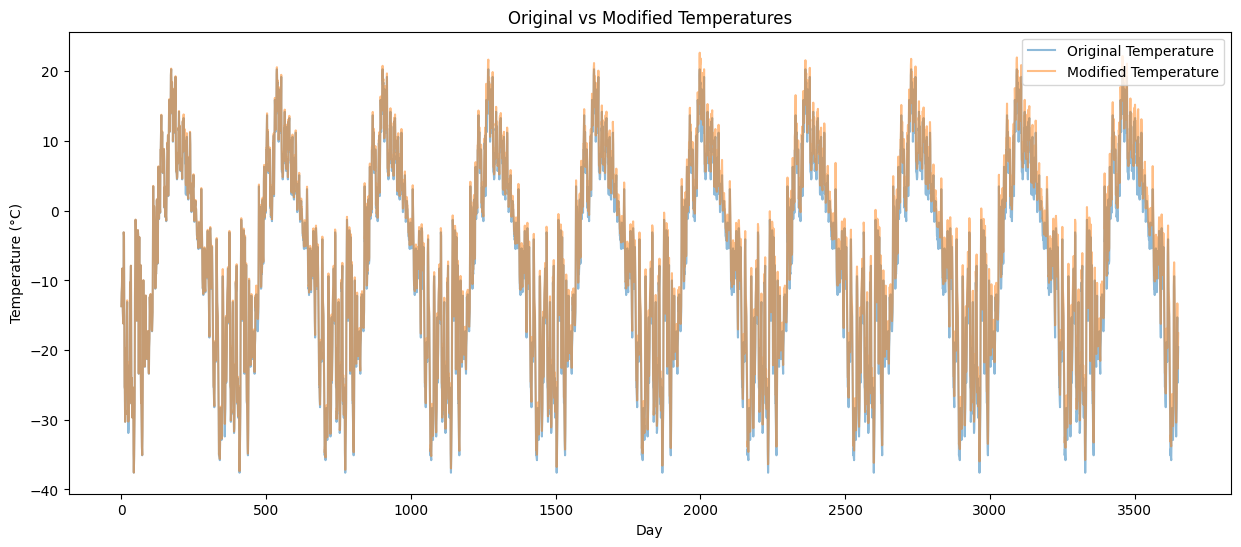

Temperature comparison plot saved as 'temperature_comparison.png'


In [7]:
# Optional: Plot the original and modified temperatures
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(df['day'], df['temperature'], label='Original Temperature', alpha=0.5)
plt.plot(df['day'], df['modified_temperature'], label='Modified Temperature', alpha=0.5)
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.title('Original vs Modified Temperatures')
plt.legend()
# plt.savefig('temperature_comparison.png')
plt.show()
# plt.close()

# print("Temperature comparison plot saved as 'temperature_comparison.png'")